In [137]:
# Data Preprocessing and Normalization
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os
import joblib

def clean_currency_columns(df):
    """
    Clean currency columns that contain '$' and convert to float
    """
    currency_columns = ['per_capita_income', 'yearly_income', 'total_debt', 'credit_limit']

    for col in currency_columns:
        if col in df.columns:
            # Remove '$' and ',' then convert to float
            df[col] = (df[col]
                       .astype(str)
                       .str.replace('$', '', regex=False)
                       .str.replace(',', '', regex=False)
                       .replace('nan', np.nan)
                       .replace('None', np.nan))

            # Convert to numeric, errors='coerce' will convert invalid parsing to NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


def prepare_user_features(df):
    """
    Prepare and normalize user features properly
    """
    # Clean currency columns first
    df = clean_currency_columns(df)

    # Fill missing values with median for numerical columns
    numerical_cols = ['current_age', 'credit_score', 'num_credit_cards',
                      'per_capita_income', 'yearly_income', 'total_debt',
                      'credit_limit', 'latitude', 'longitude']

    for col in numerical_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Encode categorical variables
    categorical_encoders = {}
    categorical_cols = ['use_chip', 'gender', 'card_brand', 'card_type',
                        'has_chip', 'card_on_dark_web']

    for col in categorical_cols:
        if col in df.columns:
            encoder = LabelEncoder()
            df[col + '_encoded'] = encoder.fit_transform(df[col].fillna('unknown'))
            categorical_encoders[col] = encoder

    return df, categorical_encoders


def create_user_feature_vector(user_data):
    """
    Create a proper user feature vector with all relevant features
    """
    def clean_currency(value):
        if isinstance(value, str):
            # Remove '$' and ',' from currency values
            return float(value.replace('$', '').replace(',', ''))
        return float(value)

    features = []

    # Spending patterns (already calculated)
    features.extend([
        float(user_data.get('avg_amount', 0)),
        float(user_data.get('std_amount', 0)),
        float(user_data.get('transaction_count', 0)),
        clean_currency(user_data.get('total_spent', 0))
    ])

    # Demographics
    features.extend([
        float(user_data.get('current_age', 0)),
        float(user_data.get('credit_score', 0)),
        float(user_data.get('num_credit_cards', 0)),
        clean_currency(user_data.get('per_capita_income', 0)),
        clean_currency(user_data.get('yearly_income', 0)),
        clean_currency(user_data.get('total_debt', 0)),
        clean_currency(user_data.get('credit_limit', 0))
    ])

    # Location features
    features.extend([
        float(user_data.get('latitude', 0)),
        float(user_data.get('longitude', 0))
    ])

    # Encoded categorical features
    features.extend([
        float(user_data.get('use_chip_encoded', 0)),
        float(user_data.get('gender_encoded', 0)),
        float(user_data.get('card_brand_encoded', 0)),
        float(user_data.get('card_type_encoded', 0)),
        float(user_data.get('has_chip_encoded', 0)),
        float(user_data.get('card_on_dark_web_encoded', 0))
    ])

    return np.array(features, dtype=np.float32)


def improved_data_preprocessing():
    """
    Complete improved data preprocessing pipeline
    """
    # Load data
    transactions_df = pd.read_csv('../dataset/transactions_data.csv')
    transactions_df = transactions_df.sample(frac=0.01, random_state=42).reset_index(drop=True)
    users_df = pd.read_csv('../dataset/users_data.csv')
    cards_df = pd.read_csv('../dataset/cards_data.csv')

    # Load MCC codes
    with open('../dataset/mcc_codes.json', 'r') as f:
        mcc_codes = json.load(f)

    # Merge dataframes
    df = transactions_df.merge(users_df, left_on='client_id', right_on='id',
                               how='left', suffixes=('', '_user'))
    df = df.merge(cards_df, left_on='card_id', right_on='id',
                  how='left', suffixes=('', '_card'))

    # Drop unwanted columns
    df = df.drop(columns=['id_user', 'id_card', 'client_id_card'], errors='ignore')

    # Clean and preprocess data
    df, categorical_encoders = prepare_user_features(df)

    # Feature engineering
    df['date'] = pd.to_datetime(df['date'])
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # Clean amount column
    df['amount'] = (df['amount']
                    .astype(str)
                    .str.replace('$', '', regex=False)
                    .astype(float)
                    .apply(lambda x: abs(x)))

    # MCC encoding
    mcc_encoder = LabelEncoder()
    df['mcc_encoded'] = mcc_encoder.fit_transform(df['mcc'].fillna('unknown'))

    # User spending patterns
    user_stats = df.groupby('client_id').agg({
        'amount': ['mean', 'std', 'sum'],
        'date': ['count']
    }).reset_index()
    user_stats.columns = ['client_id', 'avg_amount', 'std_amount', 'total_spent', 'transaction_count']

    df = df.merge(user_stats, on='client_id', how='left')

    return df, mcc_encoder, categorical_encoders


def create_sequences_improved(df, client_id, sequence_length=30, forecast_horizon=7):
    """
    Improved sequence creation with proper feature handling
    """
    user_data = df[df['client_id'] == client_id].sort_values('date')

    if len(user_data) < sequence_length + forecast_horizon:
        return None, None, None

    # Features for sequence input (normalized)
    sequence_features = [
        'amount', 'mcc_encoded', 'hour', 'day_of_week',
        'month', 'is_weekend'
    ]

    # User features (to be normalized separately)
    user_feature_names = [
        'avg_amount', 'std_amount', 'transaction_count', 'total_spent',
        'current_age', 'credit_score', 'num_credit_cards',
        'per_capita_income', 'yearly_income', 'total_debt', 'credit_limit',
        'latitude', 'longitude',
        'use_chip_encoded', 'gender_encoded', 'card_brand_encoded',
        'card_type_encoded', 'has_chip_encoded', 'card_on_dark_web_encoded'
    ]

    X, y, user_features = [], [], []

    for i in range(len(user_data) - sequence_length - forecast_horizon + 1):
        # Sequence data
        seq_data = user_data.iloc[i:i + sequence_length][sequence_features].values
        X.append(seq_data)

        # Target
        future_data = user_data.iloc[i + sequence_length:i + sequence_length + forecast_horizon]
        future_expenses = future_data['amount'].sum()
        y.append([future_expenses])

        # User features (same for all sequences of this user)
        user_row = user_data.iloc[i]
        user_feat = create_user_feature_vector(user_row)
        user_features.append(user_feat)

    return np.array(X), np.array(y), np.array(user_features)


def normalize_all_features(X_combined, user_features_array):
    """
    Properly normalize both sequence and user features
    """
    print("Normalizing sequence features...")
    # Normalize sequence features
    n_samples, seq_len, n_features = X_combined.shape
    X_reshaped = X_combined.reshape(-1, n_features)

    sequence_scaler = StandardScaler()
    X_scaled = sequence_scaler.fit_transform(X_reshaped)
    X_combined_scaled = X_scaled.reshape(n_samples, seq_len, n_features)

    print("Normalizing user features...")
    # Normalize user features
    user_scaler = StandardScaler()
    user_features_scaled = user_scaler.fit_transform(user_features_array)

    return X_combined_scaled, user_features_scaled, sequence_scaler, user_scaler

def main_preprocessing_pipeline():
    """
    Main preprocessing pipeline
    """
    # Step 1: Load and preprocess data
    df, mcc_encoder, categorical_encoders = improved_data_preprocessing()

    # Step 2: Create sequences for all users
    client_ids = df['client_id'].unique()
    all_X, all_y, all_user_features = [], [], []

    print(f"Processing {len(client_ids)} unique clients...")

    for client_id in tqdm(client_ids, desc="Creating sequences"):
        X, y, user_feat = create_sequences_improved(df, client_id)
        if X is not None:
            all_X.append(X)
            all_y.append(y)
            all_user_features.append(user_feat)

    # Step 3: Combine all data
    X_combined = np.vstack(all_X)
    y_combined = np.vstack(all_y)
    user_features_combined = np.vstack(all_user_features)

    # Step 4: Normalize features properly
    X_scaled, user_features_scaled, seq_scaler, user_scaler = normalize_all_features(
        X_combined, user_features_combined
    )

    # Step 5: Split data
    indices = np.arange(len(X_scaled))
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)

    # Create splits
    X_train, X_val, X_test = X_scaled[train_idx], X_scaled[val_idx], X_scaled[test_idx]
    y_train, y_val, y_test = y_combined[train_idx], y_combined[val_idx], y_combined[test_idx]
    user_train = user_features_scaled[train_idx]
    user_val = user_features_scaled[val_idx]
    user_test = user_features_scaled[test_idx]

    # Save scalers and encoders
    scalers_and_encoders = {
        'sequence_scaler': seq_scaler,
        'user_scaler': user_scaler,
        'mcc_encoder': mcc_encoder,
        'categorical_encoders': categorical_encoders
    }

    return {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'user_train': user_train, 'user_val': user_val, 'user_test': user_test,
        'scalers_encoders': scalers_and_encoders
    }


# Additional utility functions
def save_preprocessing_artifacts(data_dict, save_dir='preprocessed_data/'):
    """
    Save all preprocessing artifacts
    """
    import os
    import joblib

    os.makedirs(save_dir, exist_ok=True)

    # Save arrays
    np.savez(f'{save_dir}/processed_data.npz',
             X_train=data_dict['X_train'],
             X_val=data_dict['X_val'],
             X_test=data_dict['X_test'],
             y_train=data_dict['y_train'],
             y_val=data_dict['y_val'],
             y_test=data_dict['y_test'],
             user_train=data_dict['user_train'],
             user_val=data_dict['user_val'],
             user_test=data_dict['user_test'])

    # Save scalers and encoders
    scalers = data_dict['scalers_encoders']
    for name, obj in scalers.items():
        joblib.dump(obj, f'{save_dir}/{name}.pkl')

    print(f"All preprocessing artifacts saved to {save_dir}")

def load_preprocessing_artifacts(save_dir='preprocessed_data/'):
    """
    Load all preprocessing artifacts
    """
    import joblib

    # Load arrays
    data = np.load(f'{save_dir}/processed_data.npz')

    # Load scalers and encoders
    scalers = {}
    scaler_files = ['sequence_scaler.pkl', 'user_scaler.pkl',
                    'mcc_encoder.pkl', 'categorical_encoders.pkl']

    for file in scaler_files:
        name = file.replace('.pkl', '')
        scalers[name] = joblib.load(f'{save_dir}/{file}')

    return {
        'X_train': data['X_train'], 'X_val': data['X_val'], 'X_test': data['X_test'],
        'y_train': data['y_train'], 'y_val': data['y_val'], 'y_test': data['y_test'],
        'user_train': data['user_train'], 'user_val': data['user_val'], 'user_test': data['user_test'],
        'scalers_encoders': scalers
    }

In [55]:
def save_models(model, model_name, model_dir='models/'):
    """
    Save trained models
    """
    import os
    os.makedirs(model_dir, exist_ok=True)
    model.save(f'{model_dir}/{model_name}.keras')

In [115]:
def build_lstm_model(input_shape, output_dim=2):
    """
    Build LSTM model for expense/income forecasting
    """
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

In [75]:
def build_gru_model(input_shape, output_dim=2):
    """
    Build GRU model (faster alternative)
    """
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True),
        Dropout(0.2),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(output_dim, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

In [58]:
def _calculate_metrics(y_true, y_pred, metric_type):
    """
    Calculate comprehensive metrics for predictions
    """
    # Remove any NaN or infinite values
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    if len(y_true_clean) == 0:
        return {'error': 'No valid predictions'}

    # Core metrics
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    mse = mean_squared_error(y_true_clean, y_pred_clean)
    rmse = np.sqrt(mse)

    # R-squared
    r2 = r2_score(y_true_clean, y_pred_clean)

    # MAPE (handling division by zero)
    mape = np.mean(np.abs((y_true_clean - y_pred_clean) / np.maximum(np.abs(y_true_clean), 1e-8))) * 100

    # Direction accuracy (for financial predictions)
    direction_accuracy = np.mean(np.sign(y_true_clean[1:] - y_true_clean[:-1]) ==
                                 np.sign(y_pred_clean[1:] - y_pred_clean[:-1])) * 100

    # Prediction intervals
    residuals = y_true_clean - y_pred_clean
    prediction_std = np.std(residuals)

    # Statistical tests
    _, normality_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)

    metrics = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2_Score': r2,
        'MAPE': mape,
        'Direction_Accuracy': direction_accuracy,
        'Prediction_Std': prediction_std,
        'Residuals_Normal': normality_p > 0.05,
        'Mean_Actual': np.mean(y_true_clean),
        'Mean_Predicted': np.mean(y_pred_clean),
        'Correlation': np.corrcoef(y_true_clean, y_pred_clean)[0, 1]
    }

    # Print metrics
    print(f"\n{metric_type} Prediction Metrics:")
    print(f"  MAE (Mean Absolute Error): ${mae:.2f}")
    print(f"  RMSE (Root Mean Square Error): ${rmse:.2f}")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    print(f"  Direction Accuracy: {direction_accuracy:.2f}%")
    print(f"  Prediction Standard Deviation: ${prediction_std:.2f}")
    print(f"  Actual vs Predicted Correlation: {metrics['Correlation']:.4f}")

    return metrics

In [69]:
def _grade_model_performance(expense_metrics):
    """
    Grade model performance from A+ to F
    """
    if 'error' in expense_metrics:
        return 'F'

    # Scoring criteria
    score = 0

    # R² Score (40% weight)
    r2_expense = expense_metrics.get('R2_Score', 0)
    if r2_expense > 0.9:
        score += 40
    elif r2_expense > 0.8:
        score += 35
    elif r2_expense > 0.7:
        score += 30
    elif r2_expense > 0.6:
        score += 25
    elif r2_expense > 0.5:
        score += 20
    elif r2_expense > 0.3:
        score += 15
    elif r2_expense > 0.1:
        score += 10
    else:
        score += 5

    # MAPE (30% weight)
    mape_expense = expense_metrics.get('MAPE', 100)
    if mape_expense < 5:
        score += 30
    elif mape_expense < 10:
        score += 25
    elif mape_expense < 15:
        score += 20
    elif mape_expense < 20:
        score += 15
    elif mape_expense < 30:
        score += 10
    else:
        score += 5

    # Direction Accuracy (20% weight)
    dir_acc = expense_metrics.get('Direction_Accuracy', 0)
    if dir_acc > 80:
        score += 20
    elif dir_acc > 70:
        score += 15
    elif dir_acc > 60:
        score += 10
    elif dir_acc > 50:
        score += 5

    # Correlation (10% weight)
    corr = expense_metrics.get('Correlation', 0)
    if corr > 0.9:
        score += 10
    elif corr > 0.8:
        score += 8
    elif corr > 0.7:
        score += 6
    elif corr > 0.6:
        score += 4
    elif corr > 0.5:
        score += 2

    # Grade assignment
    if score >= 90:
        return 'A+'
    elif score >= 85:
        return 'A'
    elif score >= 80:
        return 'A-'
    elif score >= 75:
        return 'B+'
    elif score >= 70:
        return 'B'
    elif score >= 65:
        return 'B-'
    elif score >= 60:
        return 'C+'
    elif score >= 55:
        return 'C'
    elif score >= 50:
        return 'C-'
    elif score >= 45:
        return 'D+'
    elif score >= 40:
        return 'D'
    else:
        return 'F'

In [60]:
def save_as_json(metrics, filename='model_performance.json'):
    """Save metrics to JSON file"""
    try:
        with open(filename, 'w') as f:
            json.dump(metrics, f, indent=4, default=str)
        print(f"Model performance saved to {filename}")
    except Exception as e:
        print(f"Error saving to JSON: {e}")

In [67]:
def evaluate_model_performance(model, X_test, y_test, model_name="Model"):
    """
    Comprehensive model evaluation with multiple metrics
    """
    print(f"\n{'=' * 50}")
    print(f"EVALUATING {model_name.upper()}")
    print(f"{'=' * 50}")

    # Make predictions
    y_pred = model.predict(X_test, verbose=0)

    # Handle multi-output models
    if len(y_pred.shape) > 2 or isinstance(y_pred, list):
        y_pred_expenses = y_pred[:, 0]
        y_test_expenses = y_test[:, 0]
    else:
        # Single output model
        y_pred_expenses = y_pred[:, 0] if y_pred.shape[1] > 1 else y_pred.flatten()
        y_test_expenses = y_test[:, 0] if len(y_test.shape) > 1 and y_test.shape[1] > 1 else y_test.flatten()

    # Calculate metrics for expenses
    expense_metrics = _calculate_metrics(y_test_expenses, y_pred_expenses, "Expenses")

    # Overall model performance
    overall_metrics = {
        'model_name': model_name,
        'expense_metrics': expense_metrics,
        'prediction_accuracy_grade': _grade_model_performance(expense_metrics)
    }

    # Store results
    save_as_json(overall_metrics, f"{model_name}_metrics.json") 

    return overall_metrics

In [62]:
def load_preprocessing_artifacts(save_dir='preprocessed_data/'):
    """
    Load previously saved preprocessing artifacts
    """
    try:
        # Load arrays
        data_file = f'{save_dir}/processed_data.npz'
        if not os.path.exists(data_file):
            print(f"❌ No saved data found at {data_file}")
            return None
            
        data = np.load(data_file)
        
        # Load scalers and encoders
        scalers_encoders = {}
        scaler_files = [f for f in os.listdir(save_dir) if f.endswith('.pkl')]
        
        for file in scaler_files:
            name = file.replace('.pkl', '')
            scalers_encoders[name] = joblib.load(f'{save_dir}/{file}')
        
        # Reconstruct data_dict
        data_dict = {
            'X_train': data['X_train'],
            'X_val': data['X_val'],
            'X_test': data['X_test'],
            'y_train': data['y_train'],
            'y_val': data['y_val'],
            'y_test': data['y_test'],
            'user_train': data['user_train'],
            'user_val': data['user_val'],
            'user_test': data['user_test'],
            'scalers_encoders': scalers_encoders
        }
        
        print(f"✅ Successfully loaded preprocessing artifacts from {save_dir}")
        return data_dict
        
    except Exception as e:
        print(f"❌ Error loading preprocessing artifacts: {e}")
        return None

def is_data_dict_valid(data_dict):
    """
    Check if data_dict contains valid data
    """
    if data_dict is None:
        return False
        
    required_keys = ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'user_train']
    
    try:
        # Check if all required keys exist
        for key in required_keys:
            if key not in data_dict:
                print(f"❌ Missing key: {key}")
                return False
                
        # Check if arrays are not empty
        for key in required_keys:
            if data_dict[key] is None or len(data_dict[key]) == 0:
                print(f"❌ Empty data for key: {key}")
                return False
                
        # Check if shapes are reasonable
        train_samples = len(data_dict['X_train'])
        if train_samples < 10:  # Minimum reasonable sample size
            print(f"❌ Too few training samples: {train_samples}")
            return False
            
        print(f"✅ Data validation passed - {train_samples} training samples")
        return True
        
    except Exception as e:
        print(f"❌ Error validating data_dict: {e}")
        return False

def get_or_load_data(force_reload=False, save_dir='preprocessed_data/'):
    """
    Smart data loading with fallback logic
    """
    data_dict = None
    
    if not force_reload:
        # First, try to run preprocessing pipeline
        print("🔄 Attempting to run preprocessing pipeline...")
        try:
            data_dict = main_preprocessing_pipeline()
            
            if is_data_dict_valid(data_dict):
                print("✅ Fresh data from preprocessing pipeline")
                # Save for future use
                save_preprocessing_artifacts(data_dict, save_dir)
                return data_dict
            else:
                print("⚠️  Preprocessing pipeline returned invalid data")
                data_dict = None
                
        except Exception as e:
            print(f"❌ Preprocessing pipeline failed: {e}")
            data_dict = None
    
    # Fallback: try to load saved data
    if data_dict is None:
        print("🔄 Attempting to load saved preprocessing artifacts...")
        data_dict = load_preprocessing_artifacts(save_dir)
        
        if is_data_dict_valid(data_dict):
            print("✅ Using saved preprocessing artifacts")
            return data_dict
        else:
            print("❌ No valid saved data found")
    
    # If we get here, both methods failed
    if data_dict is None:
        raise ValueError("❌ Unable to get valid data from either preprocessing pipeline or saved artifacts")
    
    return data_dict

# Updated save function with better error handling
def save_preprocessing_artifacts(data_dict, save_dir='preprocessed_data/'):
    """
    Save all preprocessing artifacts with validation
    """
    if not is_data_dict_valid(data_dict):
        print("❌ Cannot save invalid data_dict")
        return False
        
    try:
        os.makedirs(save_dir, exist_ok=True)

        # Save arrays
        np.savez(f'{save_dir}/processed_data.npz',
                 X_train=data_dict['X_train'],
                 X_val=data_dict['X_val'],
                 X_test=data_dict['X_test'],
                 y_train=data_dict['y_train'],
                 y_val=data_dict['y_val'],
                 y_test=data_dict['y_test'],
                 user_train=data_dict['user_train'],
                 user_val=data_dict['user_val'],
                 user_test=data_dict['user_test'])

        # Save scalers and encoders
        if 'scalers_encoders' in data_dict:
            scalers = data_dict['scalers_encoders']
            for name, obj in scalers.items():
                joblib.dump(obj, f'{save_dir}/{name}.pkl')

        print(f"✅ All preprocessing artifacts saved to {save_dir}")
        return True
        
    except Exception as e:
        print(f"❌ Error saving preprocessing artifacts: {e}")
        return False

In [63]:
"""
Train all models using the new preprocessing pipeline
"""
print("🔄 Loading preprocessed data...")

data_dict = get_or_load_data(force_reload=False)

# Extract data from the dictionary (your original code)
X_train = data_dict['X_train']
X_val = data_dict['X_val']
X_test = data_dict['X_test']
y_train = data_dict['y_train']
y_val = data_dict['y_val']
y_test = data_dict['y_test']
user_train = data_dict['user_train']

print(f"📊 Dataset shapes:")
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"   X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"   User features: {user_train.shape}")

🔄 Loading preprocessed data...
🔄 Attempting to run preprocessing pipeline...
Processing 1219 unique clients...


Creating sequences: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1219/1219 [00:22<00:00, 53.65it/s]


Normalizing sequence features...
Normalizing user features...
✅ Data validation passed - 71609 training samples
✅ Fresh data from preprocessing pipeline
✅ Data validation passed - 71609 training samples
✅ All preprocessing artifacts saved to preprocessed_data/
📊 Dataset shapes:
   X_train: (71609, 30, 6), y_train: (71609, 1)
   X_val: (8951, 30, 6), y_val: (8951, 1)
   X_test: (8952, 30, 6), y_test: (8952, 1)
   User features: (71609, 19)


In [116]:
# Extract data from the dictionary
X_train = data_dict['X_train']
X_val = data_dict['X_val']
X_test = data_dict['X_test']
y_train = data_dict['y_train']
y_val = data_dict['y_val']
y_test = data_dict['y_test']
user_train = data_dict['user_train']

print(f"📊 Dataset shapes:")
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"   X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"   User features: {user_train.shape}")

# Define callbacks for training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Train LSTM model
print("\n🔧 Training LSTM model...")
lstm_model = build_lstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    output_dim=y_train.shape[1] if len(y_train.shape) > 1 else 1
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

save_models(lstm_model, 'lstm_model')

📊 Dataset shapes:
   X_train: (71609, 30, 6), y_train: (71609, 1)
   X_val: (8951, 30, 6), y_val: (8951, 1)
   X_test: (8952, 30, 6), y_test: (8952, 1)
   User features: (71609, 19)

🔧 Training LSTM model...
Epoch 1/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 65s 28ms/step - loss: 71240.3594 - mae: 192.0792 - val_loss: 52640.9297 - val_mae: 163.6782 - learning_rate: 0.0010
Epoch 2/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - loss: 50765.5234 - mae: 159.8520 - val_loss: 52347.2578 - val_mae: 160.0524 - learning_rate: 0.0010
Epoch 3/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 59s 26ms/step - loss: 44996.4219 - mae: 143.1544 - val_loss: 40491.1172 - val_mae: 131.4234 - learning_rate: 0.0010
Epoch 4/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - loss: 41337.3945 - mae: 136.3313 - val_loss: 41272.8984 - val_mae: 130.9181 - learning_rate: 0.0010
Epoch 5/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - loss: 38505.3867 - mae: 132.0089 - val_loss: 38644.1484 - val_mae: 131.5363 - learning_rate: 0.0010
Ep

In [117]:
# Evaluate LSTM model
print("\n📊 Evaluating LSTM model...")
lstm_results = evaluate_model_performance(
    lstm_model, X_test, y_test, "LSTM"
)


📊 Evaluating LSTM model...

EVALUATING LSTM

Expenses Prediction Metrics:
  MAE (Mean Absolute Error): $118.66
  RMSE (Root Mean Square Error): $169.96
  R² Score: 0.4239
  MAPE (Mean Absolute Percentage Error): 45.17%
  Direction Accuracy: 72.14%
  Prediction Standard Deviation: $169.38
  Actual vs Predicted Correlation: 0.6604
Model performance saved to LSTM_metrics.json


In [76]:
# Train GRU model for comparison
print("\n🔧 Training GRU model...")
gru_model = build_gru_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    output_dim=y_train.shape[1] if len(y_train.shape) > 1 else 1
)

history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

save_models(gru_model, 'gru_model')


🔧 Training GRU model...
Epoch 1/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 65s 28ms/step - loss: 70495.3672 - mae: 189.9022 - val_loss: 41523.6758 - val_mae: 134.6055 - learning_rate: 0.0010
Epoch 2/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 60s 27ms/step - loss: 41624.5000 - mae: 138.6578 - val_loss: 41930.7578 - val_mae: 130.4830 - learning_rate: 0.0010
Epoch 3/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 59s 27ms/step - loss: 41405.3438 - mae: 136.7871 - val_loss: 40571.3828 - val_mae: 135.0634 - learning_rate: 0.0010
Epoch 4/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - loss: 41713.8203 - mae: 137.4598 - val_loss: 40701.5352 - val_mae: 129.6655 - learning_rate: 0.0010
Epoch 5/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - loss: 40610.2578 - mae: 135.0210 - val_loss: 39759.5078 - val_mae: 133.3380 - learning_rate: 0.0010
Epoch 6/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 61s 27ms/step - loss: 40581.1992 - mae: 135.6895 - val_loss: 40001.6367 - val_mae: 130.8960 - learning_rate: 0.0010
Epoch 7/10
2238/2238 ━━━━━━

In [77]:
# Evaluate GRU model
print("\n📊 Evaluating GRU model...")
gru_results = evaluate_model_performance(
    gru_model, X_test, y_test, "GRU"
)


📊 Evaluating GRU model...

EVALUATING GRU

Expenses Prediction Metrics:
  MAE (Mean Absolute Error): $125.82
  RMSE (Root Mean Square Error): $184.10
  R² Score: 0.3240
  MAPE (Mean Absolute Percentage Error): 48.92%
  Direction Accuracy: 70.72%
  Prediction Standard Deviation: $184.04
  Actual vs Predicted Correlation: 0.5709
Model performance saved to GRU_metrics.json


In [81]:
def build_improved_lstm_model(input_shape, output_dim=1):
    from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.regularizers import l2
    
    model = Sequential([
        Input(shape=input_shape),
        
        # більше LSTM шарів з BatchNorm
        LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),
        
        LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),
        
        LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),
        
        LSTM(32, dropout=0.2, recurrent_dropout=0.2),
        BatchNormalization(),
        
        # Dense шари з regularization
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(output_dim, activation='linear')
    ])
    
    # кращий оптимізатор з adaptive learning rate
    model.compile(
        optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
        loss='huber',  # Більш стійка до викидів ніж MSE
        metrics=['mae', 'mape']
    )
    
    return model

In [82]:
# Train improved LSTM model
print("\n🔧 Training improved LSTM model...")
lstm_improved_model = build_improved_lstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    output_dim=y_train.shape[1] if len(y_train.shape) > 1 else 1
)

history_lstm = lstm_improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

save_models(lstm_improved_model, 'lstm_improved_model')


🔧 Training improved LSTM model...
Epoch 1/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 354s 156ms/step - loss: 180.9736 - mae: 181.2760 - mape: 63.7332 - val_loss: 145.8850 - val_mae: 146.1855 - val_mape: 45.1909 - learning_rate: 0.0010
Epoch 2/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 340s 152ms/step - loss: 139.2730 - mae: 139.5751 - mape: 50.5894 - val_loss: 139.4711 - val_mae: 139.7731 - val_mape: 52.4175 - learning_rate: 0.0010
Epoch 3/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 339s 151ms/step - loss: 137.8625 - mae: 138.1671 - mape: 48.9849 - val_loss: 131.8279 - val_mae: 132.1390 - val_mape: 45.5208 - learning_rate: 0.0010
Epoch 4/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 343s 153ms/step - loss: 136.8180 - mae: 137.1301 - mape: 49.4709 - val_loss: 132.4953 - val_mae: 132.8102 - val_mape: 49.4459 - learning_rate: 0.0010
Epoch 5/10
2238/2238 ━━━━━━━━━━━━━━━━━━━━ 354s 158ms/step - loss: 135.3770 - mae: 135.6963 - mape: 48.6417 - val_loss: 133.0245 - val_mae: 133.3486 - val_mape: 51.1839 - learning_rate: 0.0010
Epoch

In [83]:
# Evaluate GRU model
print("\n📊 Evaluating LSTM improved model...")
lstm_improved_results = evaluate_model_performance(
    lstm_improved_model, X_test, y_test, "LSTM-improved"
)


📊 Evaluating LSTM improved model...

EVALUATING LSTM-IMPROVED

Expenses Prediction Metrics:
  MAE (Mean Absolute Error): $127.55
  RMSE (Root Mean Square Error): $200.29
  R² Score: 0.1998
  MAPE (Mean Absolute Percentage Error): 44.57%
  Direction Accuracy: 69.95%
  Prediction Standard Deviation: $196.23
  Actual vs Predicted Correlation: 0.4845
Model performance saved to LSTM-improved_metrics.json


In [101]:
def hyperparameter_search(X_train, y_train, X_val, y_val, input_shape):
    import keras_tuner as kt
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Input, LSTM, Dense
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping

    def build_tuned_model(hp):
        model = Sequential([
            Input(shape=input_shape),
            
            LSTM(
                hp.Int('lstm_1_units', 64, 512, step=64),
                return_sequences=True,
                dropout=hp.Float('dropout_1', 0.1, 0.5, step=0.1)
            ),
            
            LSTM(
                hp.Int('lstm_2_units', 32, 256, step=32),
                return_sequences=hp.Boolean('return_sequences'),
                dropout=hp.Float('dropout_2', 0.1, 0.5, step=0.1)
            ),
            
            Dense(
                hp.Int('dense_units', 16, 128, step=16),
                activation='relu'
            ),
            
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
            loss='mse',
            metrics=['mae']
        )
        
        return model

    tuner = kt.RandomSearch(
        build_tuned_model,
        objective='val_loss',
        max_trials=20,
        directory='tuner_dir',
        project_name='lstm_hyperparam_search'
    )

    # Early stopping for faster convergence
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Run the search
    tuner.search(X_train, y_train,
                 validation_data=(X_val, y_val),
                 epochs=10,
                 batch_size=32,
                 callbacks=[early_stop],
                 verbose=1)

    # Retrieve best model
    best_model = tuner.get_best_models(num_models=1)[0]
    best_hps = tuner.get_best_hyperparameters(1)[0]

    return best_model, best_hps


In [102]:
input_shape = (X_train.shape[1], X_train.shape[2])
best_model, best_hps = hyperparameter_search(X_train, y_train, X_val, y_val, input_shape)

print('best_model', best_model)
print('best_hps', best_hps)

Trial 20 Complete [00h 14m 39s]
val_loss: 40455.5078125

Best val_loss So Far: 40306.76171875
Total elapsed time: 07h 44m 01s
best_model <Sequential name=sequential, built=True>
best_hps <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x3b4ecab70>


/Users/iryna/Projects/SET/DL-capstone-project/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [104]:
best_hps.values

{'lstm_1_units': 128,
 'dropout_1': 0.1,
 'lstm_2_units': 224,
 'return_sequences': False,
 'dropout_2': 0.30000000000000004,
 'dense_units': 80,
 'learning_rate': 0.003448238582327038}

In [108]:
print("Best hyperparameters:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")

Best hyperparameters:
lstm_1_units: 128
dropout_1: 0.1
lstm_2_units: 224
return_sequences: False
dropout_2: 0.30000000000000004
dense_units: 80
learning_rate: 0.003448238582327038


In [110]:
# Combine training and validation sets
X_full_train = np.concatenate([X_train, X_val])
y_full_train = np.concatenate([y_train, y_val])

# Rebuild model using best hyperparameters
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam

def rebuild_best_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True, dropout=0.1),
        LSTM(224, return_sequences=False, dropout=0.3),
        Dense(80, activation='relu'),
        Dense(1, activation='linear')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.003448238582327038),
        loss='mse',
        metrics=['mae']
    )
    return model

best_model = rebuild_best_model(input_shape)
best_model.fit(X_full_train, y_full_train, epochs=50, batch_size=32, verbose=1)

Epoch 1/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 116s 46ms/step - loss: 58282.8750 - mae: 170.0047
Epoch 2/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 113s 45ms/step - loss: 52097.6953 - mae: 160.5909
Epoch 3/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 107s 43ms/step - loss: 52406.8203 - mae: 160.7301
Epoch 4/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 104s 41ms/step - loss: 52134.3008 - mae: 160.5292
Epoch 5/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 113s 45ms/step - loss: 52402.8867 - mae: 160.4095
Epoch 6/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 108s 43ms/step - loss: 47875.7734 - mae: 152.3575
Epoch 7/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 107s 43ms/step - loss: 43622.9023 - mae: 141.3906
Epoch 8/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 107s 43ms/step - loss: 42440.8711 - mae: 139.2837
Epoch 9/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 115s 46ms/step - loss: 41830.2891 - mae: 138.6663
Epoch 10/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 114s 45ms/step - loss: 42364.3438 - mae: 138.4692
Epoch 11/50
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 114s 45ms/step - loss: 41724.6055 - 

In [111]:
save_models(best_model, 'best_model')

In [112]:
# Evaluate best_model model
print("\n📊 Evaluating best model...")
best_model_results = evaluate_model_performance(
    best_model, X_test, y_test, "best_model"
)


📊 Evaluating best model...

EVALUATING BEST_MODEL

Expenses Prediction Metrics:
  MAE (Mean Absolute Error): $140.81
  RMSE (Root Mean Square Error): $198.69
  R² Score: 0.2126
  MAPE (Mean Absolute Percentage Error): 59.96%
  Direction Accuracy: 69.15%
  Prediction Standard Deviation: $196.95
  Actual vs Predicted Correlation: 0.4779
Model performance saved to best_model_metrics.json


In [113]:
def compare_models(X_test, y_test):
    """
    Compare all trained models
    """
    print(f"\n{'=' * 60}")
    print("MODEL COMPARISON SUMMARY")
    print(f"{'=' * 60}")
    evaluation_results = {
        'lstm': lstm_results,
        'gru': gru_results,
        'lstm_improved': lstm_improved_results,
        'best_model': best_model_results
    }
    comparison_data = []

    for model_name, results in evaluation_results.items():
        expense_metrics = results['expense_metrics']
        grade = results['prediction_accuracy_grade']

        comparison_data.append({
            'Model': model_name,
            'Grade': grade,
            'R²': expense_metrics.get('R2_Score', 0),
            'RMSE': expense_metrics.get('RMSE', 0),
            'MAPE': expense_metrics.get('MAPE', 0),
            'Direction_Acc': expense_metrics.get('Direction_Accuracy', 0)
        })

    # Create comparison DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('R²', ascending=False)

    print(comparison_df.to_string(index=False, float_format='%.3f'))

    # Recommendation
    best_model = comparison_df.iloc[0]['Model']
    print(f"\n🏆 RECOMMENDED MODEL: {best_model}")
    print(f"   Grade: {comparison_df.iloc[0]['Grade']}")
    print(f"   R² Score: {comparison_df.iloc[0]['R²']:.4f}")

    return comparison_df

In [114]:
compare_models(X_test, y_test)


MODEL COMPARISON SUMMARY
        Model Grade    R²    RMSE   MAPE  Direction_Acc
         lstm     F 0.411 171.823 47.685         71.813
          gru     F 0.324 184.097 48.919         70.718
   best_model     F 0.213 198.686 59.964         69.154
lstm_improved     F 0.200 200.294 44.573         69.947

🏆 RECOMMENDED MODEL: lstm
   Grade: F
   R² Score: 0.4111


,Model,Grade,R²,RMSE,MAPE,Direction_Acc
0,lstm,F,0.411145,171.822662,47.684989,71.813205
1,gru,F,0.324008,184.097103,48.919283,70.718355
3,best_model,F,0.212621,198.686292,59.963776,69.154284
2,lstm_improved,F,0.199829,200.293801,44.572545,69.947492


In [ ]:
print(history_lstm.history.keys())

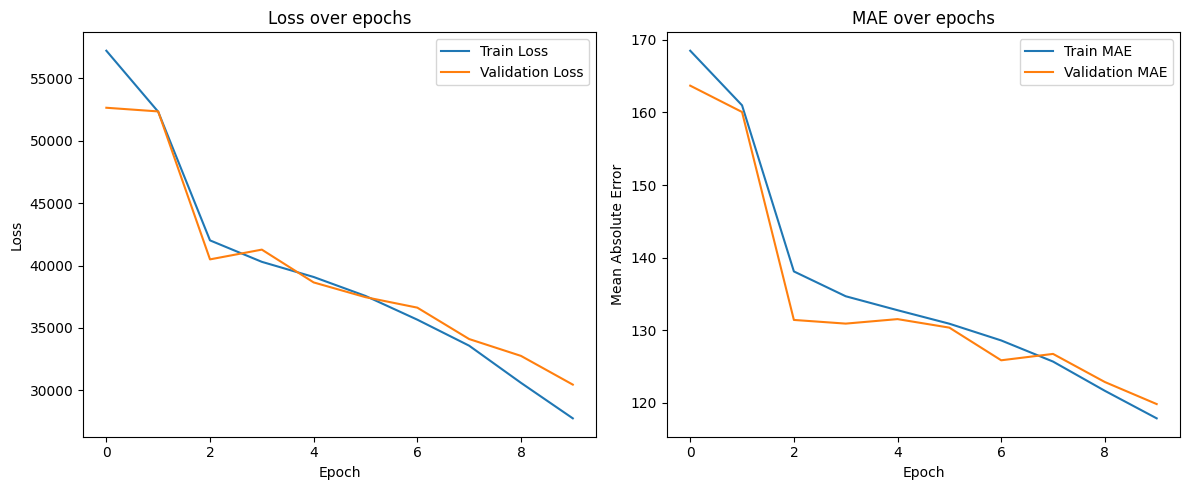

In [120]:
import matplotlib.pyplot as plt

# loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# accuracy
if 'mse' in history_lstm.history:
    plt.subplot(1, 2, 2)
    plt.plot(history_lstm.history['mse'], label='Train MSE')
    plt.plot(history_lstm.history['val_mse'], label='Validation MSE')
    plt.title('MSE over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.legend()
if 'mae' in history_lstm.history:
    plt.subplot(1, 2, 2)
    plt.plot(history_lstm.history['mae'], label='Train MAE')
    plt.plot(history_lstm.history['val_mae'], label='Validation MAE')
    plt.title('MAE over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()

plt.tight_layout()
plt.show()


In [121]:
def load_preprocessing_artifacts(save_dir='preprocessed_data/'):
    """
    Load all preprocessing artifacts
    """
    import joblib

    # Load arrays
    data = np.load(f'{save_dir}/processed_data.npz')

    # Load scalers and encoders
    scalers = {}
    scaler_files = ['sequence_scaler.pkl', 'user_scaler.pkl',
                    'mcc_encoder.pkl', 'categorical_encoders.pkl']

    for file in scaler_files:
        name = file.replace('.pkl', '')
        scalers[name] = joblib.load(f'{save_dir}/{file}')

    return {
        'X_train': data['X_train'], 'X_val': data['X_val'], 'X_test': data['X_test'],
        'y_train': data['y_train'], 'y_val': data['y_val'], 'y_test': data['y_test'],
        'user_train': data['user_train'], 'user_val': data['user_val'], 'user_test': data['user_test'],
        'scalers_encoders': scalers
    }

In [142]:
def predict_user_forecast(user_data_sequence, user_features=None):
    """
    Generate predictions for a user
    """
    # Load the model
    model = tf.keras.models.load_model('models/lstm_model.keras')
    
    # Load preprocessing artifacts
    data_dict = load_preprocessing_artifacts()
    sequence_scaler = data_dict['scalers_encoders']['sequence_scaler']
    user_scaler = data_dict['scalers_encoders']['user_scaler']
    
    # Scale the input sequence
    user_data_scaled = sequence_scaler.transform(
        user_data_sequence.reshape(-1, user_data_sequence.shape[-1])
    ).reshape(user_data_sequence.shape)

    # Scale user features if available
    if user_features is not None:
        user_features_scaled = user_scaler.transform(user_features)
    else:
        user_features_scaled = None

    # Make prediction 
    prediction = model.predict(user_data_scaled, verbose=0)

    # Format predictions
    return {
        'next_week_expenses': float(prediction[0][0])
    }

In [140]:
def load_and_predict(user_data, client_id):
    # Create sequences for prediction
    Q, z, user_features = create_sequences_improved(user_data, client_id)
    
    if Q is None:
        return "Not enough data for prediction. Need at least 30 days of transaction history."
    
    # Get the last sequence for prediction
    last_sequence = Q[-1:]
    
    # Make prediction
    return predict_user_forecast(last_sequence, user_features[-1:] if user_features is not None else None)

In [143]:
test_df = pd.read_csv('../dataset/random_user_transactions.csv')
test_id = 771

result = load_and_predict(test_df, test_id)
print(result)


{'next_week_expenses': 450.01104736328125}
